# 06 - Results and the suggested threshold

This is the summary notebook. It puts every approach on one table, applies a fixed decision rule to pick a winner,
explains the result boundaries once more with the final numbers, and ends with a concrete value for `rerank_min_score`
and the text for ADR-007. **Everything is computed from the caches; nothing is typed in.**

**Approaches compared**

| row | what it is |
|---|---|
| Current (cut = 0.0) | production retrieval, answer iff top-1 rerank score >= 0.0 (the placeholder shipped today) |
| Current (best absolute cut) | same retrieval, the best single absolute cut (in-sample) |
| A best | best of: raw or cleaned message x {top-1, margin, z-score, dense/lexical agreement} gate (no LLM) |
| B best | best of: LLM rewrite (intent / original rerank) x {top-1, margin, z, router, router AND top-1} gate (1 LLM call) |
| D (each variant) | agent with the search tool decides (`final_decision == ANSWER`); "D best" = best variant |

**Decision rule (fixed in advance):** the top approach by answer/refuse F1 wins only if it leads the runner-up by **>= 3 F1 points**;
otherwise the **cheaper** one of the two wins (fewer LLM calls, then fewer tokens, then lower p50 latency).

| | |
|---|---|
| **Required caches** | `runs/R3_current, A_clean, R0_lex, R1_dense` (`uv run python -m experiments.run_variants`); `judgments.json` (`uv run python -m experiments.build_pools`, then `uv run --env-file .env python -m experiments.llm.judge`) |
| **For B rows** | `rewrites.json` (`uv run --env-file .env python -m experiments.llm.rewrite`) + re-run `run_variants` for `runs/B_rewrite_*` |
| **For D rows** | `d_runs/<variant>/*.json` (`uv run --env-file .env python -m experiments.llm.agent_d --variant d_hidden_b3`, ...). Run `build_pools` after them so their passages get judged. |

Missing pieces: the rows that depend on them are left out, the notebook still runs, and the recommendation says which rows it had.
Without `judgments.json` the labels are **provisional** (ANS vs OOD/ADJ only) and every result below is marked so.

In [1]:
import sys, pathlib, math, warnings
warnings.filterwarnings("ignore")
_here = pathlib.Path.cwd().resolve()
REPO = next(p for p in [_here, *_here.parents] if (p / "experiments" / "lab").is_dir())
sys.path[:0] = [str(REPO), str(REPO / "experiments")]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lab import notebook_utils as nu

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})
print("cache directory:", nu.cache_dir())

cache directory: /home/user/cato-networks/experiments/cache


In [2]:
RUNS = nu.load_runs(["R3_current", "A_clean", "R0_lex", "R1_dense", "B_rewrite_intent", "B_rewrite_orig"])
RW = nu.load_rewrites()
VARS = nu.d_variants()
D = {v: nu.load_d_runs(v) for v in VARS}
Q = nu.load_queries()
J = nu.load_judgments()
HAVE_J = J is not None
QR = nu.qrels_from(J)
labels = nu.gold_labels(Q, J)
should = labels["label"].dropna().astype(bool)
HAVE_BASE = all(n in RUNS for n in ("R3_current", "A_clean", "R0_lex", "R1_dense"))
HAVE_B = RW is not None and "B_rewrite_intent" in RUNS and "B_rewrite_orig" in RUNS
nu.need(HAVE_BASE, "runs R3_current, A_clean, R0_lex, R1_dense", nu.CMD_RUN_VARIANTS)
nu.need(HAVE_J, "judgments.json (real gold labels and hit@k)", nu.CMD_POOLS + " ; " + nu.CMD_JUDGE)
nu.need(HAVE_B, "rewrites.json + B runs (row B)", nu.CMD_REWRITE)
nu.need(bool(VARS), "d_runs (rows D)", nu.CMD_AGENT)
print(nu.label_banner(labels))
PROVISIONAL = "" if HAVE_J else " [PROVISIONAL LABELS]"

SKIPPED - missing cache: judgments.json (real gold labels and hit@k)
  Run step first: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge
SKIPPED - missing cache: rewrites.json + B runs (row B)
  Run step first: uv run --env-file .env python -m experiments.llm.rewrite   (then re-run: uv run python -m experiments.run_variants)
SKIPPED - missing cache: d_runs (rows D)
  Run step first: uv run --env-file .env python -m experiments.llm.agent_d --variant d_hidden_b3   (repeat for the other variants)
PROVISIONAL LABELS: 57 of 57 labelled queries use the query-set prior (ANS=answerable, OOD/ADJ=unanswerable; SCN/TKT unlabelled). Run the judge to get real labels: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge


## 1. Build every approach's answer/refuse decisions

In [3]:
APP = {}   # name -> dict(did, signal, run, llm_calls, tokens, p50_ms, hit1, hit5)
_pq = {}
def pq(run):
    if run not in _pq and HAVE_J:
        _pq[run] = nu.per_query_metrics(RUNS[run], QR)
    return _pq.get(run)

def run_ms(run, extra=None):
    ms = pd.Series({i: v["latency_ms"] for i, v in RUNS[run].items()})
    return nu.p50(ms + (extra.reindex(ms.index) if extra is not None else 0))

def add(name, family, did, signal, run, llm_calls=0.0, tokens=0.0, p50_ms=math.nan, hits=None):
    m = pq(run) if run else None
    h1, h5 = (hits if hits else ((m["hit@1"].mean(), m["hit@5"].mean()) if m is not None else (math.nan, math.nan)))
    APP[name] = {"family": family, "did": did, "signal": signal, "run": run, "llm_calls": llm_calls, "tokens": tokens,
                 "p50_ms": p50_ms, "hit1": h1, "hit5": h5}

FEATS = {}
if nu.need(HAVE_BASE and len(should) > 0, "base runs + labels", nu.CMD_RUN_VARIANTS):
    FEATS = {n: nu.gate_features(RUNS[n], RUNS["R0_lex"], RUNS["R1_dense"]) for n in ("R3_current", "A_clean")}
    r3 = FEATS["R3_current"]
    add("Current (cut = 0.0)", "current", (r3.loc[should.index, "top1"] >= 0.0), r3["top1"], "R3_current", p50_ms=run_ms("R3_current"))
    bc = nu.best_config({"R3_current": r3}, should, ["top1"])
    add("Current (best absolute cut)", "current", bc["did"], r3["top1"], "R3_current", p50_ms=run_ms("R3_current"))
    CFG = {"current": bc}
    bcs = [nu.best_config({"A_clean": FEATS["A_clean"]}, should, ["top1", "margin", "z", "agree_overlap", "agree_top1"]),
           nu.best_config({"R3_current": r3}, should, ["margin", "z", "agree_overlap", "agree_top1"])]
    bca = max(bcs, key=lambda b: (b["f1"], -b["false_answer_rate"]))
    CFG["A"] = bca
    add(f"A best ({bca['run']}, {bca['gate']} >= {bca['threshold']:.2f})", "A", bca["did"], FEATS[bca["run"]]["top1"], bca["run"], p50_ms=run_ms(bca["run"]))
print(list(APP))

['Current (cut = 0.0)', 'Current (best absolute cut)', 'A best (A_clean, top1 >= 2.74)']


In [4]:
if nu.need(HAVE_B and HAVE_BASE and len(should) > 0, "rewrites + B runs", nu.CMD_REWRITE):
    C = nu.rewrite_costs(RW)
    FB = {}
    for n in ("B_rewrite_intent", "B_rewrite_orig"):
        f = nu.gate_features(RUNS[n])
        kb = pd.Series({i: bool(RW[i]["is_kb_question"]) if i in RW else True for i in f.index})
        f["router_only"] = kb.astype(float); f["top1_routed"] = f["top1"].where(kb, -math.inf)
        FB[n] = f
    bcb = nu.best_config(FB, should, ["top1", "margin", "z", "router_only", "top1_routed"])
    CFG["B"] = bcb
    add(f"B best ({bcb['run']}, {bcb['gate']} >= {bcb['threshold']:.2f})", "B", bcb["did"], FB[bcb["run"]]["top1"], bcb["run"],
        llm_calls=float(C["requests"].mean()), tokens=float((C["in_tokens"] + C["out_tokens"]).mean()), p50_ms=run_ms(bcb["run"], C["latency_ms"]))
    print("B chosen:", bcb["run"], bcb["gate"])

SKIPPED - missing cache: rewrites + B runs
  Run step first: uv run --env-file .env python -m experiments.llm.rewrite   (then re-run: uv run python -m experiments.run_variants)


In [5]:
def first_search_hits(recs):
    h1, h5 = [], []
    for qid, r in recs.items():
        g2 = {p for p, g in QR.get(qid, {}).items() if g >= 2}
        ids = r["searches"][0]["passage_ids"] if r.get("searches") else []
        if g2:
            h1.append(float(bool(ids[:1]) and ids[0] in g2)); h5.append(float(bool(g2 & set(ids[:5]))))
    return (float(np.mean(h1)), float(np.mean(h5))) if h1 else (math.nan, math.nan)

if nu.need(bool(VARS) and len(should) > 0, "d_runs", nu.CMD_AGENT):
    DT = {v: nu.d_table(D[v], labels, QR if HAVE_J else None) for v in VARS}
    for v, t in DT.items():
        lab = t["label"].dropna().astype(bool)
        add(f"D {v}", "D", (t.loc[lab.index, "final"] == "ANSWER"), t["max_score"], None, llm_calls=float(t["requests"].mean()),
            tokens=float((t["in_tokens"] + t["out_tokens"]).mean()), p50_ms=nu.p50(t["latency_s"] * 1000),
            hits=first_search_hits(D[v]) if HAVE_J else None)
    print("D variants:", VARS)

SKIPPED - missing cache: d_runs
  Run step first: uv run --env-file .env python -m experiments.llm.agent_d --variant d_hidden_b3   (repeat for the other variants)


# RESULT TABLE - all approaches

`F1` = answer/refuse F1 (answer class) against the gold label. `false-answer rate` = share of unanswerable queries that were answered.
`false-refusal rate` = share of answerable queries that were not answered. `hit@1/5` = a grade-2 passage is in the top 1 / 5 (for D: of the
agent's first search). Latency is p50 per query; `extra tokens` are the LLM tokens (input + output) per query beyond the raw pipeline.
Gate thresholds are chosen in-sample on these same queries (optimistic); CIs are bootstrap 95% over queries.

In [6]:
def table_row(name, a):
    did = a["did"]; lab = should.loc[did.index]
    m = nu.decision_metrics(lab.tolist(), did.tolist())
    ci = nu.bootstrap_ci(nu.f1_stat(lab.tolist(), did.tolist()), len(lab))
    return {"approach": name, "family": a["family"], "answer F1": m["f1"], "F1 95% CI": f"[{ci[1]:.2f}, {ci[2]:.2f}]",
            "false-answer rate": m["false_answer_rate"], "false-refusal rate": m["false_refusal_rate"], "hit@1": a["hit1"], "hit@5": a["hit5"],
            "p50 latency ms": a["p50_ms"], "LLM calls/query": a["llm_calls"], "extra tokens/query": a["tokens"], "queries": len(lab)}

ALL = pd.DataFrame()
if nu.need(bool(APP), "at least the base runs", nu.CMD_RUN_VARIANTS):
    ALL = pd.DataFrame([table_row(n, a) for n, a in APP.items()]).set_index("approach")
    display(ALL.drop(columns="family"))
    print(nu.label_banner(labels))

,answer F1,F1 95% CI,false-answer rate,false-refusal rate,hit@1,hit@5,p50 latency ms,LLM calls/query,extra tokens/query,queries
approach,,,,,,,,,,
Current (cut = 0.0),0.819,"[0.72, 0.90]",0.636,0.029,NaN,NaN,1667.700,0.000,0.000,57
Current (best absolute cut),0.880,"[0.79, 0.95]",0.318,0.057,NaN,NaN,1667.700,0.000,0.000,57
"A best (A_clean, top1 >= 2.74)",0.880,"[0.79, 0.95]",0.318,0.057,NaN,NaN,1678.200,0.000,0.000,57


PROVISIONAL LABELS: 57 of 57 labelled queries use the query-set prior (ANS=answerable, OOD/ADJ=unanswerable; SCN/TKT unlabelled). Run the judge to get real labels: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge


## 2. Recommendation (rule applied in code)

In [7]:
WINNER, WHY = "", ""
if nu.need(len(ALL) > 0, "result table", nu.CMD_RUN_VARIANTS):
    fam_best = {}
    for fam in ("current", "A", "B", "D"):
        rows = ALL[(ALL["family"] == fam) & ~ALL.index.str.contains("cut = 0.0")]
        if len(rows):
            fam_best[fam] = rows.sort_values(["answer F1", "false-answer rate"], ascending=[False, True]).index[0]
    cand = ALL.loc[list(fam_best.values())].reset_index().rename(columns={"approach": "name", "answer F1": "f1", "LLM calls/query": "llm_calls",
                                                                        "extra tokens/query": "tokens", "p50 latency ms": "p50_ms"})
    WINNER, WHY = nu.recommend(cand, margin=0.03)
    from IPython.display import Markdown
    display(cand[["name", "f1", "llm_calls", "tokens", "p50_ms"]].sort_values("f1", ascending=False).set_index("name"))
    display(Markdown(f"### **RECOMMENDATION{PROVISIONAL}: {WINNER}**\n\n**{WHY}.** Candidates compared: {', '.join(fam_best.values())}."))

,f1,llm_calls,tokens,p50_ms
name,,,,
Current (best absolute cut),0.880,0.000,0.000,1667.700
"A best (A_clean, top1 >= 2.74)",0.880,0.000,0.000,1678.200


### **RECOMMENDATION [PROVISIONAL LABELS]: Current (best absolute cut)**

**Current (best absolute cut) leads A best (A_clean, top1 >= 2.74) by only 0.0 F1 points (< 3), so the cheaper one wins: Current (best absolute cut).** Candidates compared: Current (best absolute cut), A best (A_clean, top1 >= 2.74).

In [8]:
if nu.need(len(ALL) > 0 and bool(WINNER), "result table", nu.CMD_RUN_VARIANTS):
    # is the gap between the two best families larger than noise? (paired bootstrap on the shared labelled queries)
    ranked_f = cand.sort_values("f1", ascending=False)
    if len(ranked_f) >= 2:
        a, b = ranked_f.iloc[0]["name"], ranked_f.iloc[1]["name"]
        ids = APP[a]["did"].index.intersection(APP[b]["did"].index)
        lab = should.loc[ids].to_numpy()
        d = nu.bootstrap_diff(nu.f1_stat(lab, APP[a]["did"].loc[ids].to_numpy()), nu.f1_stat(lab, APP[b]["did"].loc[ids].to_numpy()), len(ids))
        print(f"Paired bootstrap, F1({a}) - F1({b}) = {d['diff']:+.3f}, 95% CI [{d['lo']:+.3f}, {d['hi']:+.3f}] on {len(ids)} queries; "
              f"{'zero is inside the interval: the gap is not distinguishable from noise' if d['lo'] <= 0 <= d['hi'] else 'the interval excludes zero'}.")

Paired bootstrap, F1(Current (best absolute cut)) - F1(A best (A_clean, top1 >= 2.74)) = +0.000, 95% CI [+0.000, +0.000] on 57 queries; zero is inside the interval: the gap is not distinguishable from noise.


# Result boundaries explained (final)

What the rerank score can and cannot tell. Everything below uses the **production retrieval** (`R3_current`), the score the service gates on
today. The recommended approach's decisions are cross-tabulated against the gold label at the end of this section.

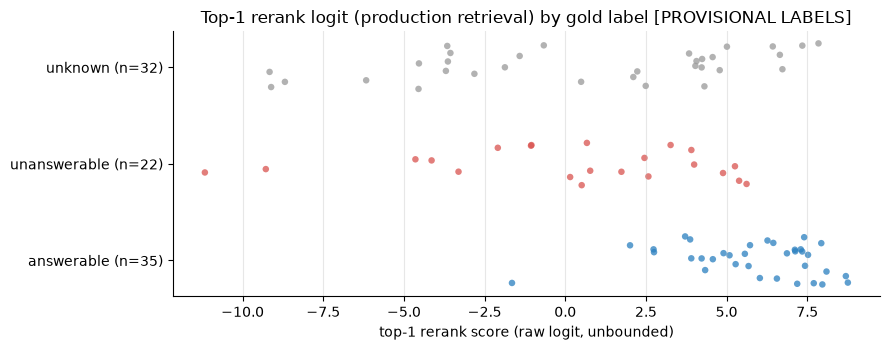

answerable queries  : n=35, top-1 min -1.65, median 6.27, max 8.76
unanswerable queries: n=22, top-1 min -11.17, median 0.72, max 5.62
AUC 0.899 | unanswerable queries scoring above the LOWEST answerable score: 16 of 22 | answerable queries scoring below the HIGHEST unanswerable score: 14 of 35


,score band,queries,answerable,unanswerable,unknown
0,< -5,6,0,2,4
1,-5 .. 0,17,1,6,10
2,0 .. 3,14,3,7,4
3,3 .. 6,28,12,7,9
4,>= 6,24,19,0,5


In [9]:
if nu.need("R3_current" in RUNS and len(should) > 0, "run R3_current + labels", nu.CMD_RUN_VARIANTS):
    r3 = nu.gate_features(RUNS["R3_current"])
    lbl = labels["label"]
    fig, ax = plt.subplots(figsize=(9, 3.6))
    g = {n: r3.loc[[i for i in r3.index if nu.label_name(lbl.get(i)) == n], "top1"] for n in ("answerable", "unanswerable", "unknown")}
    nu.strip(ax, {k: v for k, v in g.items() if len(v)}, nu.LABEL_COLORS)
    ax.set_title("Top-1 rerank logit (production retrieval) by gold label" + PROVISIONAL); ax.set_xlabel("top-1 rerank score (raw logit, unbounded)")
    plt.tight_layout(); plt.show()
    ans, un = r3.loc[should[should].index, "top1"], r3.loc[should[~should].index, "top1"]
    print(f"answerable queries  : n={len(ans)}, top-1 min {ans.min():.2f}, median {ans.median():.2f}, max {ans.max():.2f}")
    print(f"unanswerable queries: n={len(un)}, top-1 min {un.min():.2f}, median {un.median():.2f}, max {un.max():.2f}")
    print(f"AUC {nu.auc(r3['top1'], should):.3f} | unanswerable queries scoring above the LOWEST answerable score: {int((un > ans.min()).sum())} of {len(un)} | "
          f"answerable queries scoring below the HIGHEST unanswerable score: {int((ans < un.max()).sum())} of {len(ans)}")
    display(nu.band_table(r3["top1"], lbl, [-5, 0, 3, 6]))

In [10]:
if nu.need(bool(WINNER) and WINNER in APP, "recommended approach", nu.CMD_RUN_VARIANTS):
    a = APP[WINNER]; lab = should.loc[a["did"].index]
    xt = pd.crosstab(pd.Series(np.where(lab, "answerable", "unanswerable"), index=lab.index, name="gold label"),
                     pd.Series(np.where(a["did"], "answered", "refused"), index=lab.index, name="system"))
    print(f"{WINNER}: decisions vs gold label")
    display(xt)

Current (best absolute cut): decisions vs gold label


system,answered,refused
gold label,,
answerable,33,2
unanswerable,7,15


# Suggested threshold

## (1) Is a score gate still needed for the recommended approach?

We add the safety floor from section (2) on top of the recommended approach's own decisions and see what it changes. Rule: keep it if it removes at least one
false answer and does not lower F1 by more than half a point.

In [11]:
FLOOR = {}
if nu.need("R3_current" in RUNS and len(should) > 0, "run R3_current + labels", nu.CMD_RUN_VARIANTS):
    FLOOR = nu.safety_floor(r3["top1"], should, max_false_refusal=0.05, decimals=2)
    print(f"safety floor (<= 5% false refusal of answerable queries): exact {FLOOR['exact']:.3f}, rounded up {FLOOR['rounded_up']:.2f}, final {FLOOR['final']:.2f} ({FLOOR['note']})")

safety floor (<= 5% false refusal of answerable queries): exact 2.007, rounded up 2.01, final 2.00 (rounding up would breach the false-refusal budget, so rounded down)


In [12]:
if nu.need(bool(FLOOR) and bool(WINNER) and WINNER in APP, "floor + recommended approach", nu.CMD_RUN_VARIANTS):
    a = APP[WINNER]; ids = a["did"].index; lab = should.loc[ids]
    sig = a["signal"].reindex(ids).astype(float).fillna(-math.inf)
    if a["family"] in ("current", "A"):   # same retrieval as production: use the production score
        sig = r3["top1"].reindex(ids)
    with_floor = a["did"] & (sig >= FLOOR["final"])
    m0, m1 = nu.decision_metrics(lab.tolist(), a["did"].tolist()), nu.decision_metrics(lab.tolist(), with_floor.tolist())
    fa0, fa1 = int((a["did"] & ~lab).sum()), int((with_floor & ~lab).sum())
    fr0, fr1 = int((~a["did"] & lab).sum()), int((~with_floor & lab).sum())
    cmp_ = pd.DataFrame({"without floor": [m0["f1"], fa0, fr0], f"with floor >= {FLOOR['final']:.2f}": [m1["f1"], fa1, fr1]},
                        index=["answer F1", "false answers (count)", "false refusals (count)"])
    display(cmp_)
    if fa0 - fa1 >= 1 and m1["f1"] >= m0["f1"] - 0.005:
        GATE_VERDICT = f"YES - keep the floor as a safety net: it removes {fa0 - fa1} false answer(s) at a cost of {fr1 - fr0} extra false refusal(s) (F1 {m0['f1']:.3f} -> {m1['f1']:.3f})."
    elif fa0 == fa1:
        GATE_VERDICT = f"NO - the floor changes nothing for {WINNER} (it removes 0 false answers); {WINNER}'s own decision already covers it."
    else:
        GATE_VERDICT = f"NO - the floor removes {fa0 - fa1} false answer(s) but costs {fr1 - fr0} false refusal(s) and lowers F1 {m0['f1']:.3f} -> {m1['f1']:.3f}."
    print("Score gate still needed for", WINNER + "?", GATE_VERDICT)

,without floor,with floor >= 2.00
answer F1,0.880,0.880
false answers (count),7.000,7.000
false refusals (count),2.000,2.000


Score gate still needed for Current (best absolute cut)? NO - the floor changes nothing for Current (best absolute cut) (it removes 0 false answers); Current (best absolute cut)'s own decision already covers it.


## (2) Safety-floor threshold on the rerank logit

Definition: the highest cut-off `t` (answer iff top-1 rerank score >= `t`) that still refuses **at most 5%** of the gold-answerable queries.
It is deliberately conservative: it is a floor that removes hopeless matches, **not** a separator of right from wrong (section above shows none exists).
The table shows the sweep around it; the curve shows the trade-off.

In [13]:
if nu.need(bool(FLOOR), "floor", nu.CMD_RUN_VARIANTS):
    sw = nu.sweep_gate(r3["top1"], should)
    sw["unanswerable removed"] = 1 - sw["false_answer_rate"]
    view = sw[np.isfinite(sw["threshold"]) & (sw["false_refusal_rate"] <= 0.20)][["threshold", "false_refusal_rate", "unanswerable removed", "f1", "fn", "fp"]]
    view = view.rename(columns={"false_refusal_rate": "false-refusal rate", "f1": "answer F1", "fn": "answerable refused", "fp": "unanswerable answered"})
    display(view.iloc[::max(1, len(view) // 14)].set_index("threshold"))

,false-refusal rate,unanswerable removed,answer F1,answerable refused,unanswerable answered
threshold,,,,,
-11.169,0.000,0.000,0.761,0,22
-9.281,0.000,0.045,0.769,0,21
-4.644,0.000,0.091,0.778,0,20
-4.143,0.000,0.136,0.787,0,19
-3.308,0.000,0.182,0.795,0,18
-2.091,0.000,0.227,0.805,0,17
-1.651,0.000,0.273,0.814,0,16
-1.062,0.029,0.273,0.800,1,16
-1.048,0.029,0.318,0.810,1,15


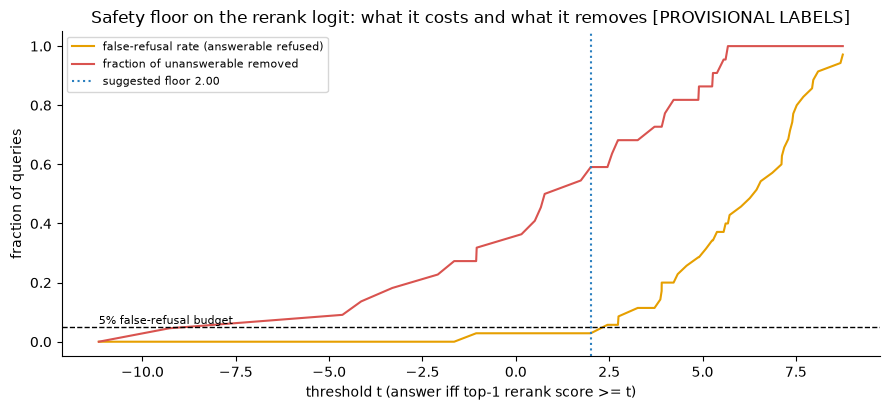

In [14]:
if nu.need(bool(FLOOR), "floor", nu.CMD_RUN_VARIANTS):
    fin = sw[np.isfinite(sw["threshold"])]
    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.plot(fin["threshold"], fin["false_refusal_rate"], color="#e69f00", label="false-refusal rate (answerable refused)")
    ax.plot(fin["threshold"], fin["unanswerable removed"], color="#d9534f", label="fraction of unanswerable removed")
    ax.axhline(0.05, color="k", ls="--", lw=1); ax.text(fin["threshold"].min(), 0.06, "5% false-refusal budget", fontsize=8)
    ax.axvline(FLOOR["final"], color="#2a7fbf", ls=":", lw=1.5, label=f"suggested floor {FLOOR['final']:.2f}")
    ax.set_title("Safety floor on the rerank logit: what it costs and what it removes" + PROVISIONAL)
    ax.set_xlabel("threshold t (answer iff top-1 rerank score >= t)"); ax.set_ylabel("fraction of queries"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## (3) Final suggested value for `core/config.py` `rerank_min_score`

Rounded **up** to 2 decimals as plan 04 required, unless that would push one more answerable query under the cut (then the notebook rounds down and says so).

In [15]:
if nu.need(bool(FLOOR), "floor", nu.CMD_RUN_VARIANTS):
    t = FLOOR["final"]
    frr = float((r3.loc[should[should].index, "top1"] < t).mean())
    removed = float((r3.loc[should[~should].index, "top1"] < t).mean())
    n_ref = int((r3.loc[should[should].index, "top1"] < t).sum()); n_un = int((~should).sum())
    still = int((r3.loc[should[~should].index, "top1"] >= t).sum())
    SUGGESTED = pd.Series({"rerank_min_score (suggested)": t, "current default": 0.0, "exact boundary score": FLOOR["exact"],
                           "answerable queries": FLOOR["n_answerable"], "allowed refusals at 5%": FLOOR["allowed_refusals"],
                           "answerable refused at suggested value": n_ref, "false-refusal rate at suggested value": frr,
                           "unanswerable queries": n_un, "unanswerable removed by the floor": f"{removed:.1%} ({n_un - still} of {n_un})",
                           "unanswerable still above the floor": still})
    display(SUGGESTED.to_frame("value"))
    from IPython.display import Markdown
    display(Markdown(f"### **SUGGESTED `rerank_min_score = {t:.2f}`**{PROVISIONAL}"))

,value
rerank_min_score (suggested),2.000
current default,0.000
exact boundary score,2.007
answerable queries,35
allowed refusals at 5%,1
answerable refused at suggested value,1
false-refusal rate at suggested value,0.029
unanswerable queries,22
unanswerable removed by the floor,59.1% (13 of 22)
unanswerable still above the floor,9


### **SUGGESTED `rerank_min_score = 2.00`** [PROVISIONAL LABELS]

Where does the floor bite? The same floor, by query set: how many gold-answerable queries of each set it refuses, and how many unlabelled queries
(SCN/TKT before judgments exist) sit under it. A floor chosen mostly from the easy ANS questions can be too high for messy real tickets, whose correct
articles score lower (notebook 01), so check the SCN and TKT rows.

In [16]:
if nu.need(bool(FLOOR), "floor", nu.CMD_RUN_VARIANTS):
    t = FLOOR["final"]
    by_set = pd.DataFrame({"set": Q["set"], "top1": r3["top1"].reindex(Q.index), "label": [nu.label_name(labels["label"].get(i)) for i in Q.index]})
    by_set["below floor"] = by_set["top1"] < t
    display(by_set.groupby(["label", "set"]).agg(queries=("top1", "size"), refused_by_floor=("below floor", "sum"), share_refused=("below floor", "mean")))

queries  refused_by_floor  share_refused
label        set                                          
answerable   ANS       35                 1          0.029
unanswerable ADJ       12                 5          0.417
             OOD       10                 8          0.800
unknown      SCN       12                10          0.833
             TKT       20                 5          0.250

## Text for ADR-007 (plain text, generated from the numbers above)

In [17]:
if nu.need(bool(FLOOR) and bool(WINNER), "floor + recommendation", nu.CMD_RUN_VARIANTS):
    auc_v = nu.auc(r3["top1"], should)
    adr = f'''ADR-007 - KB answer/refuse decision and rerank_min_score{PROVISIONAL}

Context
  The retrieval pipeline reranks with a cross-encoder whose score is a raw, unbounded logit (observed {r3["top1"].replace(-math.inf, np.nan).min():.2f} to {r3["top1"].max():.2f}).
  A single absolute threshold cannot separate answerable from unanswerable queries: ROC AUC of the top-1 score is {auc_v:.2f}
  (answerable top-1 min {ans.min():.2f}; unanswerable top-1 max {un.max():.2f}; {int((un > ans.min()).sum())} of {len(un)} unanswerable queries score above the lowest answerable one).
  {nu.label_banner(labels)}.

Decision
  Recommended approach: {WINNER}. Rule: winner needs >= 3 F1 points over the next best, else the cheaper one. {WHY}.
  Score gate for that approach: {GATE_VERDICT if "GATE_VERDICT" in globals() else "not evaluated"}
  core/config.py: rerank_min_score = {FLOOR["final"]:.2f} (was 0.0), used as a SAFETY FLOOR only, defined as the highest cut that refuses
  at most 5% of the gold-answerable queries ({n_ref} of {FLOOR["n_answerable"]} refused = {frr:.1%}). It removes {removed:.1%} of the unanswerable queries ({n_un - still} of {n_un}).

Consequences
  The floor removes only hopeless matches; most wrong-but-confident answers must be stopped by the approach's own decision logic, not by the score.
  Small sample: {len(should)} labelled queries; bootstrap 95% intervals in the result table are wide, in-sample thresholds are optimistic.
  Re-run notebooks 01-06 (and re-judge) whenever the KB corpus, the reranker model or the query set changes.'''
    print(adr)

ADR-007 - KB answer/refuse decision and rerank_min_score [PROVISIONAL LABELS]

Context
  The retrieval pipeline reranks with a cross-encoder whose score is a raw, unbounded logit (observed -11.17 to 8.76).
  A single absolute threshold cannot separate answerable from unanswerable queries: ROC AUC of the top-1 score is 0.90
  (answerable top-1 min -1.65; unanswerable top-1 max 5.62; 16 of 22 unanswerable queries score above the lowest answerable one).
  PROVISIONAL LABELS: 57 of 57 labelled queries use the query-set prior (ANS=answerable, OOD/ADJ=unanswerable; SCN/TKT unlabelled). Run the judge to get real labels: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge.

Decision
  Recommended approach: Current (best absolute cut). Rule: winner needs >= 3 F1 points over the next best, else the cheaper one. Current (best absolute cut) leads A best (A_clean, top1 >= 2.74) by only 0.0 F1 points (< 3), so the cheaper one wins: Current (best absolute